In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("Salary_Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [32]:
df.shape

(6704, 6)

In [33]:
df.shape

(6704, 6)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [35]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [36]:
df = df.dropna()

In [37]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [38]:
df.duplicated().sum()

4911

In [39]:
df = df.drop_duplicates()

In [40]:
df.duplicated().sum()

0

In [41]:
df.shape

(1787, 6)

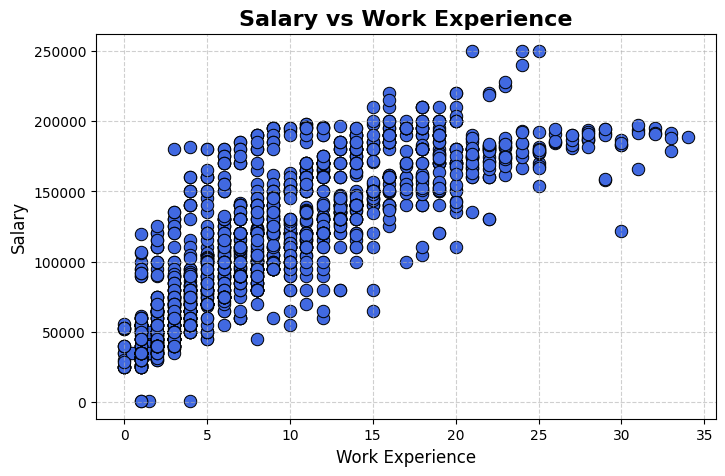

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Work Experience",
    y="Salary",
    data=df,
    color="royalblue",
    s=80,
    edgecolor="black"
)

plt.title("Salary vs Work Experience", fontsize=16, fontweight="bold")
plt.xlabel("Work Experience", fontsize=12)
plt.ylabel("Salary", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [44]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [45]:
df = df.rename(columns={
    "Education Level": "Qualification",
    "Job Title": "Designation",
    "Years of Experience": "Work Experience"
})

In [46]:
df.columns

Index(['Age', 'Gender', 'Qualification', 'Designation', 'Work Experience',
       'Salary'],
      dtype='object')

In [47]:
df_encoded = pd.get_dummies(df, columns=["Gender", "Qualification", "Designation"], drop_first=True)

In [48]:
df_encoded.head()

,Age,Work Experience,Salary,Gender_Male,Gender_Other,Qualification_Bachelor's Degree,Qualification_High School,Qualification_Master's,Qualification_Master's Degree,Qualification_PhD,...,Designation_Supply Chain Manager,Designation_Technical Recruiter,Designation_Technical Support Specialist,Designation_Technical Writer,Designation_Training Specialist,Designation_UX Designer,Designation_UX Researcher,Designation_VP of Finance,Designation_VP of Operations,Designation_Web Developer
0,32.0,5.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,36.0,7.0,60000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,20.0,200000.0,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [49]:
X = df_encoded.drop("Salary", axis=1)
y = df_encoded["Salary"]

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.831552496380352
MSE: 461536104.8030982


In [54]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.831552496380352
MSE: 461536104.8030982
MAE: 15741.892161247055
RMSE: 21483.391371082413


In [58]:
print(f"Model Accuracy (R2): {r2_score(y_test, y_pred)*100:.2f}%")

Model Accuracy (R2): 83.16%


### __Actual vs Predicted Salary Plot__

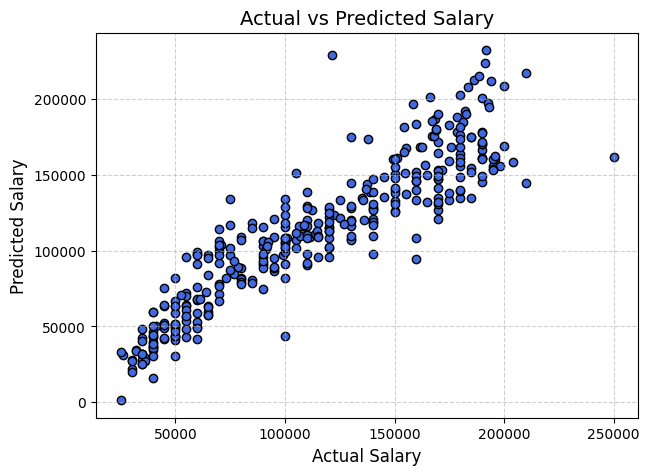

In [59]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color="royalblue", edgecolor="black")
plt.xlabel("Actual Salary", fontsize=12)
plt.ylabel("Predicted Salary", fontsize=12)
plt.title("Actual vs Predicted Salary", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### __Residual Plot__

__Residuals = Actual Salary − Predicted Salary__.

This shows whether the model errors are randomly distributed.

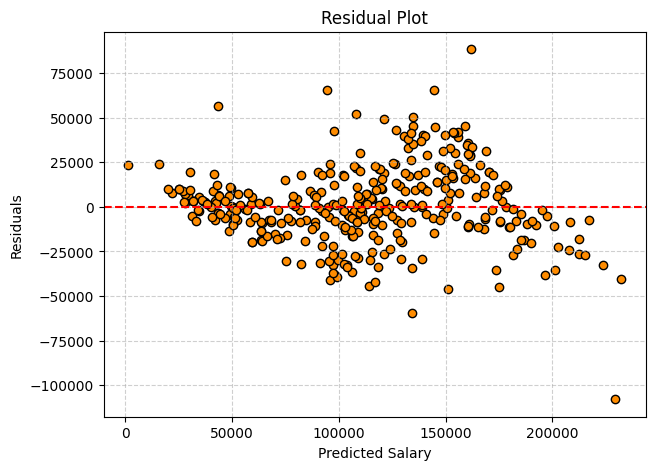

In [60]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, color="darkorange", edgecolor="black")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### __Residual Distribution Plot__

This checks whether errors follow a normal distribution.

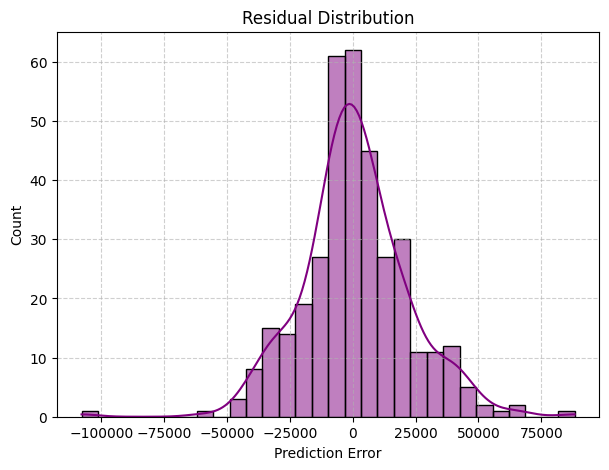

In [61]:
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=30, kde=True, color="purple")
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [63]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coefficients.sort_values(by="Coefficient", ascending=False)

,Coefficient
Designation_Chief Data Officer,106602.794235
Designation_Chief Technology Officer,100373.945829
Designation_Director of Data Science,90986.370637
Designation_Marketing Director,85406.866324
Designation_Research Director,82554.180305
...,...
Designation_Event Coordinator,-36446.632661
Designation_Training Specialist,-39796.753838
Designation_Junior Business Operations Analyst,-42447.284256
Designation_Administrative Assistant,-43627.140503


In [67]:
coefficients.sort_values(by="Coefficient").head(10)

,Coefficient
Designation_Office Manager,-49492.950254
Designation_Administrative Assistant,-43627.140503
Designation_Junior Business Operations Analyst,-42447.284256
Designation_Training Specialist,-39796.753838
Designation_Event Coordinator,-36446.632661
Designation_Marketing Specialist,-34629.163473
Qualification_High School,-31191.067868
Designation_HR Generalist,-29295.742353
Designation_IT Support Specialist,-27946.833838
Designation_Supply Chain Manager,-24982.256923


In [64]:
import pickle

pickle.dump(model, open("salary_prediction_model.pkl", "wb"))

In [68]:
model.predict(X_test.iloc[[0]])
print("Actual Salary:", y_test.iloc[0])
print("Predicted Salary:", y_pred[0])

Actual Salary: 155000.0
Predicted Salary: 137174.61741162994


In [97]:
def predict_salary(age, gender, qualification, designation, experience):

    input_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender],
        "Qualification": [qualification],
        "Designation": [designation],
        "Work Experience": [experience]
    })
    # Encode categorical features
    input_encoded = pd.get_dummies(input_data)

    # Match columns used during training
    input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)

    # Predict salary
    prediction = model.predict(input_encoded)[0]

    print(f"Predicted Salary = ₹{prediction:,.2f}")

In [98]:
# Predicting for an employee with less experience

predict_salary(
    age=22,
    gender="Female",
    qualification="Bachelor",
    designation="Software Engineer",
    experience=1
)

Predicted Salary = ₹103,547.84


In [99]:
# Predicting for an employee having mid career experience

predict_salary(
    age=30,
    gender="Male",
    qualification="Master",
    designation="Data Scientist",
    experience=6
)

Predicted Salary = ₹147,488.90


In [100]:
# Predicting for an employee with 10 years of experience

predict_salary(
    age=40,
    gender="Male",
    qualification="PhD",
    designation="Senior Data Scientist",
    experience=12
)

Predicted Salary = ₹148,948.01


In [101]:
predict_salary(30, "Male", "Master", "Data Scientist", 2)


Predicted Salary = ₹137,153.72


In [102]:
predict_salary(30, "Male", "Master", "Data Scientist", 12)

Predicted Salary = ₹162,991.68


In [103]:
# Testing salary growth with experience
for exp in [1, 5, 10, 15]:
    predict_salary(30, "Male", "Master", "Data Scientist", exp)
    

Predicted Salary = ₹134,569.93
Predicted Salary = ₹144,905.11
Predicted Salary = ₹157,824.09
Predicted Salary = ₹170,743.06
